# **Modelling**

## Objectives

* Load the cleaned dataset used in the EDA notebook
* Build baseline single-feature models to establish a floor before comparing full models
* Build and compare Logistic Regression and Random Forest models to predict Test Results
* Check which features the Random Forest model relies on most
* Check whether the Random Forest model performs fairly across Gender and Insurance Provider subgroups
* Save the model comparison, feature importance, and fairness check results for use in the Tableau dashboard

## Inputs

* Cleaned dataset: Dataset/CleanData/healthcare_cleaned_deidentified.csv

## Outputs

* Dataset/CleanData/feature_importance.csv
* Dataset/CleanData/model_comparison.csv
* Dataset/CleanData/fairness_check.csv

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Healthcare_Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Healthcare_Analysis'

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

### Load clean dataset

In [5]:
# Load the cleaned dataset in
df = pd.read_csv('Dataset/CleanData/healthcare_cleaned_deidentified.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 54966 rows, 14 columns


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20


---

### Prepare Data

I am predicting Test Results from patient and administrative features. Splitting the data into training and test sets, so the models can be evaluated on patients they haven't seen during training.

In [6]:
# Splitting the dataset into features and target variable
X = df[['Age', 'Gender', 'Medical Condition', 'Admission Type', 'Insurance Provider', 'Billing Amount', 'Length of Stay']]
y = df['Test Results']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (43972, 7), Test: (10994, 7)


Before building any models I want to check the balance of the target variable in the training set since an imbalanced target could make accuracy a misleading metric on its own.

In [7]:
y_train.value_counts(normalize=True)

Test Results
Abnormal        0.335418
Normal          0.333508
Inconclusive    0.331074
Name: proportion, dtype: float64

The target is close to perfectly balanced across all three classes around 33% each for Normal, Abnormal, and Inconclusive. This means accuracy is a reasonable metric to judge the models on and it also means a majority class baseline (always predicting the most common class) will sit at around 33%, this is the bar any real model needs to clear.

In [8]:
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

Majority-class baseline accuracy: 0.3354


### Single Feature Models

I will train two separate models each using only one feature to establish a baseline before testing whether combining features improves performance. I'm using Billing Amount and Age as the two starting features since these are the numeric variables most likely to carry some signal on their own.

In [9]:
# Training a Logistic Regression model using only the Billing Amount feature
model_billing = LogisticRegression(max_iter=1000)
model_billing.fit(X_train[['Billing Amount']], y_train)
billing_preds = model_billing.predict(X_test[['Billing Amount']])
billing_acc = accuracy_score(y_test, billing_preds)
print(f"Billing Amount only - Accuracy: {billing_acc:.4f}")

Billing Amount only - Accuracy: 0.3355


In [10]:
# Training a Logistic Regression model using only the Age feature
model_age = LogisticRegression(max_iter=1000)
model_age.fit(X_train[['Age']], y_train)
age_preds = model_age.predict(X_test[['Age']])
age_acc = accuracy_score(y_test, age_preds)
print(f"Age only - Accuracy: {age_acc:.4f}")

Age only - Accuracy: 0.3331


Both single-feature models perform almost identically to the majority-class baseline (33.5%), Billing Amount alone reaches 0.3355 and Age alone reaches 0.3331. Neither feature is doing any real predictive work on its own, which fits with what the EDA notebook found none of the hypotheses showed billing or age having a meaningful relationship with the outcome variables tested.

## Combined-Feature Model

Now I will train a model using both Billing Amount and Age together to check whether combining them captures anything the single feature models missed.

In [11]:
# Training a Logistic Regression model using both features
model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train[['Billing Amount', 'Age']], y_train)
combined_preds = model_combined.predict(X_test[['Billing Amount', 'Age']])
combined_acc = accuracy_score(y_test, combined_preds)
print(f"Billing Amount + Age - Accuracy: {combined_acc:.4f}")

Billing Amount + Age - Accuracy: 0.3355


Combining Billing Amount and Age together gives the exact same accuracy as Billing Amount alone (0.3355) Age is adding nothing on top of it. This confirms these two features alone don't carry enough signal to predict Test Results so the next step is to test a wider set of features including the categorical columns to see if a model with more information and a more flexible algorithm can do better.

### Baseline Model Results

| Model | Accuracy |
|---|---|
| Majority-class baseline | 0.3350 |
| Billing Amount only | 0.3355 |
| Age only | 0.3331 |
| Billing Amount + Age combined | 0.3355 |

# Logistic Regression vs Random Forest

Now testing a wider set of features including categorical columns to compare two models properly rather than just single numeric features.

In [12]:
categorical_features = ['Gender', 'Medical Condition', 'Admission Type', 'Insurance Provider']
numeric_features = ['Age', 'Billing Amount', 'Length of Stay']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [15]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
logreg_preds = logreg_pipeline.predict(X_test)
accuracy_score(y_test, logreg_preds)

0.33636529015826816

In [16]:
# Training a Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
accuracy_score(y_test, rf_preds)

0.4168637438602874

Logistic Regression barely beats the majority-class baseline, 0.3364 versus 0.3350, essentially no better than guessing the most common class. Random Forest does noticeably better at 0.4169 around 8 percentage points above the baseline. This suggests Random Forest is picking up on some weak non-linear patterns in the data that Logistic Regression being a linear model can't capture. Even so 0.4169 is still a modest result on a 3-class problem this dataset doesn't contain strong predictive signal for Test Results which lines up with almost every hypothesis in the EDA notebook coming back non-significant.

### Feature Importance

Checking which features the Random Forest model relied on most to see whether this matches what the EDA and correlation analysis suggested.

In [17]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(rf_pipeline.named_steps['classifier'].feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15)

num__Billing Amount                         0.346365
num__Age                                    0.277346
num__Length of Stay                         0.234547
cat__Admission Type_Elective                0.009957
cat__Admission Type_Urgent                  0.009896
cat__Admission Type_Emergency               0.009839
cat__Insurance Provider_Medicare            0.009656
cat__Insurance Provider_Cigna               0.009340
cat__Medical Condition_Cancer               0.009090
cat__Insurance Provider_Aetna               0.008978
cat__Medical Condition_Diabetes             0.008887
cat__Insurance Provider_Blue Cross          0.008720
cat__Medical Condition_Obesity              0.008621
cat__Insurance Provider_UnitedHealthcare    0.008390
cat__Medical Condition_Arthritis            0.008299
dtype: float64

Billing Amount, Age and Length of Stay dominate the importance ranking (0.346, 0.277 and 0.235 respectively) together accounting for the vast majority of what the model relies on. All of the one-hot encoded categorical features, Admission Type, Insurance Provider and Medical Condition sit far below at around 0.008-0.010 each with no single category standing out. This makes sense, the three numeric features each carry their full weight as a single column while each categorical feature gets split across several small columns after one-hot encoding spreading out its contribution. It also fits with the EDA findings none of the categorical relationships tested (H2, H5) came back significant so it's consistent that none of them show up as individually important here either.

## Fairness Check by Subgroup

So far I've checked whether the raw data shows any bias, in the EDA notebook, H2 and H4 tested whether insurance provider or gender were linked to test results or billing and neither was. But that's a separate question from whether the model itself treats every group fairly. A model can be accurate overall while still performing noticeably worse for one particular group even if the training data itself wasn't biased simply because of how the model learns patterns. If that happened here it would mean the model's predictions couldn't be trusted equally for every patient which matters a lot in a healthcare context where a model like this could realistically inform real decisions. So I'm checking the Random Forest model's accuracy separately for each Gender and each Insurance Provider to see whether it's consistent across every subgroup or whether it's quietly worse for one of them.

In [ ]:
results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = rf_preds
results_df['correct'] = results_df['actual'] == results_df['predicted']

print("Random Forest accuracy by Gender:")
print(results_df.groupby('Gender')['correct'].mean())

Random Forest accuracy by Gender:
Gender
Female    0.413549
Male      0.420190
Name: correct, dtype: float64
Random Forest accuracy by Insurance Provider:
Insurance Provider
Aetna               0.426864
Blue Cross          0.421373
Cigna               0.415231
Medicare            0.400181
UnitedHealthcare    0.421005
Name: correct, dtype: float64


In [20]:
print("Random Forest accuracy by Insurance Provider:")
print(results_df.groupby('Insurance Provider')['correct'].mean())

Random Forest accuracy by Insurance Provider:
Insurance Provider
Aetna               0.426864
Blue Cross          0.421373
Cigna               0.415231
Medicare            0.400181
UnitedHealthcare    0.421005
Name: correct, dtype: float64


Accuracy by Gender ranges from 41.4% (Female) to 42.0% (Male). Accuracy by Insurance Provider ranges from 40.0% (Medicare) to 42.7% (Aetna). If either of these gaps had been large for example the model being 15 points more accurate for one insurer than another that would mean the model's predictions couldn't be trusted equally across patients and it would need investigating and likely correcting before being used for anything real even in a dataset this weak overall. A gap this small under 3 points in both cases is well within what I'd expect from normal variation across a test set of this size so there's no evidence the model is systematically under-serving any particular group. This is a genuinely useful result not just because it's reassuring but because it shows the fairness check itself is doing its job, it's specific enough that a real disparity would have shown up here if one existed.

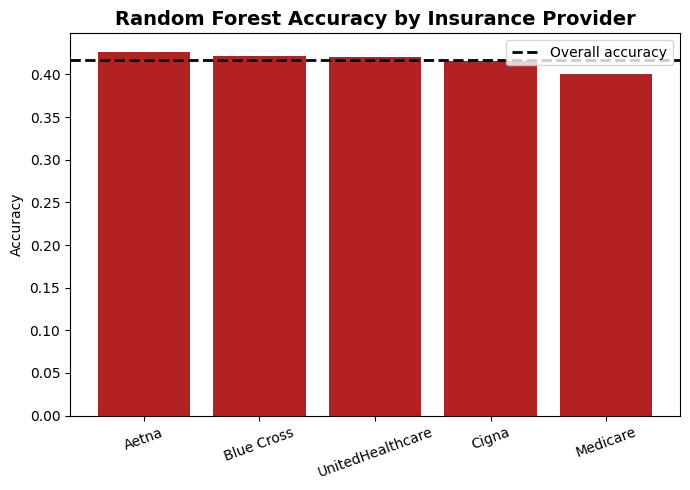

In [23]:
rf_acc = accuracy_score(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(7, 5))
insurance_acc = results_df.groupby('Insurance Provider')['correct'].mean().sort_values(ascending=False)
ax.bar(insurance_acc.index, insurance_acc.values, color='firebrick')
ax.axhline(rf_acc, color='black', linestyle='--', linewidth=2, label='Overall accuracy')
ax.set_title('Random Forest Accuracy by Insurance Provider', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
plt.xticks(rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

### Model Comparison Summary

| Model | Accuracy |
|---|---|
| Majority-class baseline | 0.3350 |
| Billing Amount only | 0.3355 |
| Age only | 0.3331 |
| Billing Amount + Age combined | 0.3355 |
| Logistic Regression (full features) | 0.3364 |
| Random Forest (full features) | 0.4169 |


Random Forest with the full feature set is the clear best performer, at 0.4169 accuracy compared to Logistic Regression's 0.3364 and the 0.3350 baseline. I'm recommending Random Forest, but with a real caveat, 41.7% on a 3-class problem is still a weak result overall and shouldn't be presented as the model reliably predicting patient outcomes. It's best understood as a demonstration that the modelling and fairness checking process works correctly not as something ready for real decision-making. The fairness check was run specifically on this stronger Random Forest model, since checking a near-baseline model for subgroup bias wouldn't be meaningful there's nothing to check for bias in if the model barely predicts anything to begin with.

Saving the feature importance, model comparison and fairness check results into my cleaned data folder so they're ready to use in the Tableau dashboard.

In [24]:
importances.sort_values(ascending=False).to_csv('Dataset/CleanData/feature_importance.csv')

model_comparison = pd.DataFrame({
    'Model': ['Majority-class baseline', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [0.3350, 0.3364, 0.4169]
})
model_comparison.to_csv('Dataset/CleanData/model_comparison.csv', index=False)

gender_fairness = results_df.groupby('Gender')['correct'].mean().reset_index().rename(columns={'correct': 'accuracy', 'Gender': 'subgroup'})
gender_fairness['subgroup_type'] = 'Gender'

insurance_fairness = results_df.groupby('Insurance Provider')['correct'].mean().reset_index().rename(columns={'correct': 'accuracy', 'Insurance Provider': 'subgroup'})
insurance_fairness['subgroup_type'] = 'Insurance Provider'

fairness_check = pd.concat([gender_fairness, insurance_fairness], ignore_index=True)
fairness_check.to_csv('Dataset/CleanData/fairness_check.csv', index=False)

# Conclusion

The modelling results tell the same story as the EDA notebook, this dataset doesn't contain much real predictive signal. Logistic Regression barely beat the baseline and even Random Forest the stronger of the two models only reached 41.7% accuracy on a 3-class problem. Billing Amount, Age and Length of Stay were the only features carrying any real weight none of the categorical features individually mattered much which lines up with H2 and H5 in the EDA notebook finding no significant relationship for Insurance Provider or Medical Condition.

The fairness check was the main new piece of work in this notebook. Where the EDA notebook checked whether the raw data showed bias H2 and H4 both found no relationship between insurance provider or gender and the outcomes this notebook checked something different whether the model itself treats every group consistently once it's trained. Accuracy stayed within a tight band across both Gender (41.4%-42.0%) and Insurance Provider (40.0%-42.7%) so there's no evidence the model is systematically worse for any particular group. Together the EDA fairness hypotheses and this model-level fairness check cover both sides of the ethics  whether the data itself carries bias and whether the AI built on top of it does too.

If this pipeline were ever applied to real hospital data, both the hypothesis tests and this fairness check would need to be re-run before trusting any of the conclusions a synthetic dataset can validate that the process works but it can't validate that a real-world model would be equally fair.


---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
